# Exploratory Data Analysis in Python
- The process of reviewing and cleaning data to
- derive insights
- generate hypotheses

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
books = pd.read_csv('../resources/clean_books.csv')
books.head()

,name,author,rating,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,2019,Childrens


In [3]:
books.info()

<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    350 non-null    str    
 1   author  350 non-null    str    
 2   rating  350 non-null    float64
 3   year    350 non-null    int64  
 4   genre   350 non-null    str    
dtypes: float64(1), int64(1), str(3)
memory usage: 38.9 KB


# A closer look at the categorical columns

In [4]:
books.value_counts("genre")

genre
Non Fiction    179
Fiction        131
Childrens       40
Name: count, dtype: int64

In [5]:
books.describe()

,rating,year
count,350.000000,350.000000
mean,4.608571,2013.508571
std,0.226941,3.284711
min,3.300000,2009.000000
25%,4.500000,2010.000000
50%,4.600000,2013.000000
75%,4.800000,2016.000000
max,4.900000,2019.000000


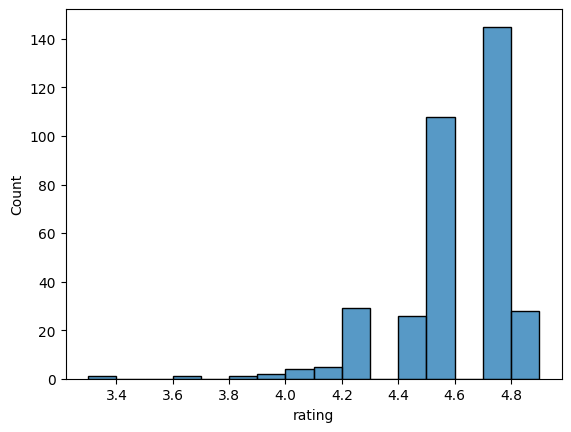

In [9]:
sns.histplot(
    data=books,
    x='rating',
    binwidth=0.1
)

plt.show()

# Data Validation

In [11]:
books.dtypes

name          str
author        str
rating    float64
year        int64
genre         str
dtype: object

In [13]:
books['year'] = books['year'].astype(int)
books.dtypes

name          str
author        str
rating    float64
year        int64
genre         str
dtype: object

In [ ]:
books['genre'].isin(['Fiction','Non Fiction'])

0      False
1      False
2      False
3      False
4       True
       ...  
345    False
346    False
347    False
348    False
349     True
Name: genre, Length: 350, dtype: bool

In [17]:
books[books['genre'].isin(['Fiction','Non Fiction'])].head()

,name,author,rating,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,2017,Fiction
5,A Dance with Dragons (A Song of Ice and Fire),George R. R. Martin,4.4,2011,Fiction


In [18]:
books.select_dtypes('number').head()

,rating,year
0,4.7,2016
1,4.6,2011
2,4.7,2018
3,4.7,2017
4,4.8,2019


In [19]:
books['year'].min()

np.int64(2009)

In [20]:
books['year'].max()

np.int64(2019)

<Axes: xlabel='year'>

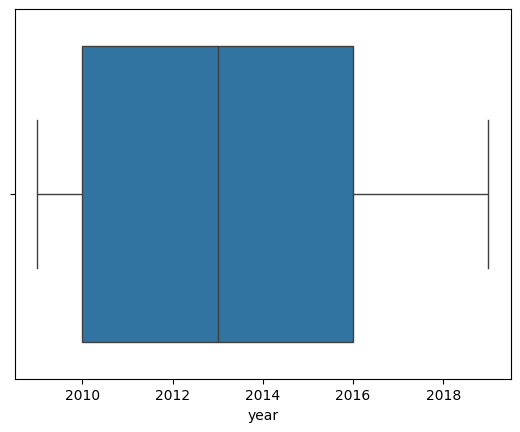

In [21]:
sns.boxplot(data=books,x='year')

<Axes: xlabel='year', ylabel='genre'>

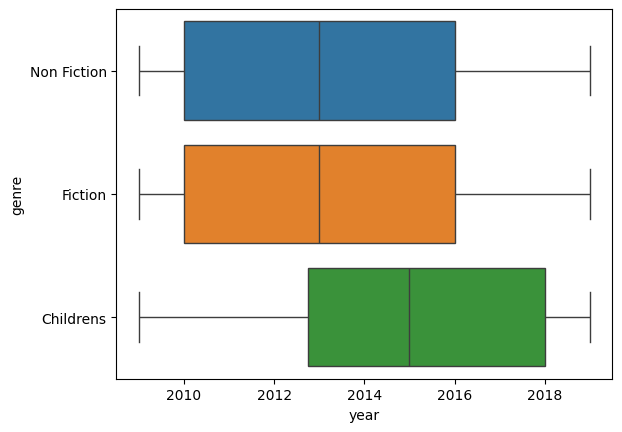

In [23]:
sns.boxplot(
    data=books,
    x='year',
    y='genre',
    hue='genre'
)

# Data Summarization

In [24]:
books[['genre','rating','year']].groupby('genre').mean()

,rating,year
genre,,
Childrens,4.780000,2015.075000
Fiction,4.570229,2013.022901
Non Fiction,4.598324,2013.513966


In [25]:
books[['rating','year']].agg(['mean','std'])

,rating,year
mean,4.608571,2013.508571
std,0.226941,3.284711


# Specifying aggregations for columns

In [26]:
books.agg({'rating':['mean','std'],"year":['median']})

,rating,year
mean,4.608571,NaN
std,0.226941,NaN
median,NaN,2013.0


In [27]:
books.groupby('genre').agg(
    mean_rating = ('rating','mean'),
    std_rating = ('rating','std'),
    median_year = ('year','median')
)

,mean_rating,std_rating,median_year
genre,,,
Childrens,4.780000,0.122370,2015.0
Fiction,4.570229,0.281123,2013.0
Non Fiction,4.598324,0.179411,2013.0


<Axes: xlabel='genre', ylabel='rating'>

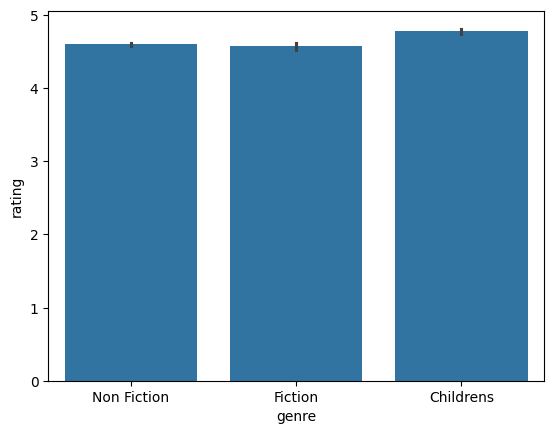

: 

In [ ]:
sns.barplot(
    data=books,
    x='genre',
    y='rating'
)